# Identification of 5 binary digit images with a raw NumPy neural network

**Homework 6 — Variant 5 (Level I).** Build a script that identifies binary images of **5 digits** given by a raster matrix. The classifier is an artificial neural network implemented "from scratch" (raw matrix operations, no ML frameworks). We justify the architecture and training algorithm and prove the network's workability **and** efficiency.

**Data.** Instead of 5 hand-drawn glyphs (one example per class, as in the lecture `Neural_Networks_numpy_2.py`), we use **MNIST** — the classic handwritten-digit dataset. We take the 5 classes **0, 1, 2, 3, 4**, binarize each 28x28 image by thresholding, and use the dataset's own train/test split. This gives a *real* generalization test: the network is trained on some handwritten samples and evaluated on different, unseen ones — so high test accuracy proves it learned to **recognize** the digits, not memorize fixed pictures.

**Pipeline:** load + binarize (MNIST) -> visualize -> build raw NumPy MLP -> train -> evaluate (accuracy, confusion matrix, sample predictions, misclassified examples).

In [13]:
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_CACHE = Path.home() / ".keras" / "datasets" / "mnist.npz"


def load_data():
    """Drop-in equivalent of keras.datasets.mnist.load_data().

    Downloads the ~11 MB MNIST npz once into the cache, then loads from disk.
    """
    if not MNIST_CACHE.exists():
        MNIST_CACHE.parent.mkdir(parents=True, exist_ok=True)
        print("downloading mnist.npz (~11 MB) ...")
        urllib.request.urlretrieve(MNIST_URL, MNIST_CACHE)
    with np.load(MNIST_CACHE) as f:
        return (f["x_train"], f["y_train"]), (f["x_test"], f["y_test"])


RNG = np.random.default_rng(42)  # single source of randomness -> reproducible run

## 1. Load and binarize the data

`load_data()` returns `uint8` images shaped `(N, 28, 28)` and integer labels `0..9`. 

We keep only the 5 digits we want (all available samples of each), then **binarize**: threshold the grayscale intensity to get a strict `{0, 1}` raster matrix, as the task requires.

In [14]:
# --- configuration (generic over any digit subset) ---
DIGITS = [0, 1, 2, 3, 4]      # the 5 classes to identify
THRESHOLD = 50               # grayscale -> binary cutoff (0..255)


def make_split(images, labels):
    """Keep only DIGITS, binarize, and flatten 28x28 -> 784 (uses all available samples).

    Returns X as a (N, 784) float {0,1} matrix and y as integer class indices 0..K-1.
    """
    binary = (images > THRESHOLD).astype(np.float64)
    X_parts, y_parts = [], []
    for class_idx, digit in enumerate(DIGITS):
        cls_images = binary[labels == digit]
        X_parts.append(cls_images.reshape(len(cls_images), -1))
        y_parts.append(np.full(len(cls_images), class_idx))
    return np.vstack(X_parts), np.concatenate(y_parts)


(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_data()
X_train, y_train = make_split(x_train_raw, y_train_raw)
X_test, y_test = make_split(x_test_raw, y_test_raw)

print(f"train: X {X_train.shape}, y {y_train.shape}")
print(f"test:  X {X_test.shape}, y {y_test.shape}")
print(f"pixel values present: {np.unique(X_train)} (strictly binary)")
print(f"classes: {dict(zip(range(len(DIGITS)), DIGITS))}")

train: X (30596, 784), y (30596,)
test:  X (5139, 784), y (5139,)
pixel values present: [0. 1.] (strictly binary)
classes: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


### Visualize the binarized inputs

A few examples per class — these are the actual `{0, 1}` raster matrices fed to the network.

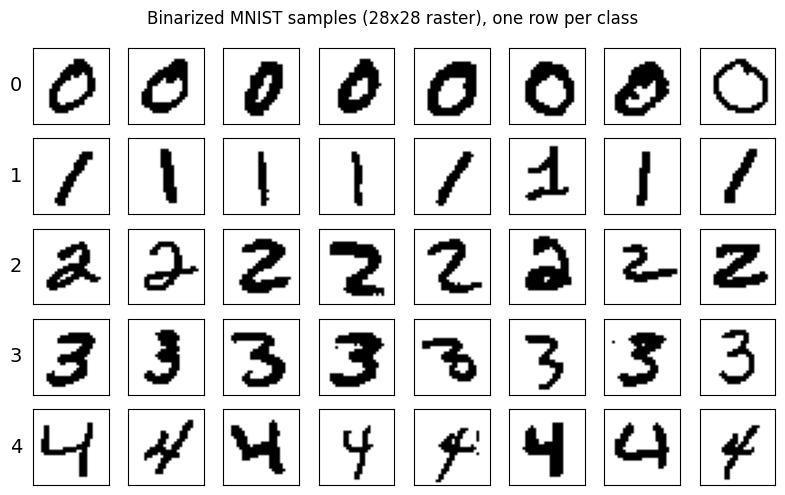

In [15]:
n_show = 8
fig, axes = plt.subplots(len(DIGITS), n_show, figsize=(n_show, len(DIGITS)))
for row, digit in enumerate(DIGITS):
    idxs = np.where(y_train == row)[0][:n_show]
    for col, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(X_train[idx].reshape(28, 28), cmap="gray_r")
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=12, fontsize=14, va="center")
fig.suptitle("Binarized MNIST samples (28x28 raster), one row per class")
plt.tight_layout()
plt.show()

## 2. Network architecture (lecture baseline)

This is the **exact architecture from the lecture** `Neural_Networks_numpy_2.py`, adapted only where the data forces it (784 inputs, 5 output classes):

```
input 784  ->  hidden 5 (sigmoid)  ->  output 5 (sigmoid)
```

- **Hidden layer of 5 sigmoid units** — same size and activation as the lecture.
- **Sigmoid output** (one unit per class); the predicted digit is the arg-max of the output.
- **MSE loss** and **plain random weight init**
- **Per-sample gradient descent** with learning rate `alpha`

This is intentionally the simple baseline; if it underperforms, iterate from here.

In [16]:
# ----- lecture baseline network: sigmoid activations, one hidden layer, MSE, no biases -----

def one_hot(y, n_classes):
    """Integer labels -> one-hot rows."""
    out = np.zeros((y.size, n_classes))
    out[np.arange(y.size), y] = 1.0
    return out


def sigmoid(x):
    """Activation used in both layers (lecture baseline)."""
    return 1.0 / (1.0 + np.exp(-x))


def generate_wt(n_in, n_out):
    """Random weight initialization (standard normal, unscaled) -- as in the lecture."""
    return RNG.standard_normal((n_in, n_out))


def f_forward(x, w1, w2):
    """Forward pass: input -> sigmoid hidden -> sigmoid output. No bias terms."""
    a1 = sigmoid(x.dot(w1))     # hidden layer
    a2 = sigmoid(a1.dot(w2))    # output layer
    return a2


def loss(out, Y):
    """Mean-square error (lecture baseline loss)."""
    return np.sum(np.square(out - Y)) / len(Y)


def back_prop(x, y, w1, w2, alpha):
    """Back-propagation for ONE sample (MSE + sigmoid), exactly as the lecture."""
    a1 = sigmoid(x.dot(w1))
    a2 = sigmoid(a1.dot(w2))
    d2 = (a2 - y)
    d1 = np.multiply((w2.dot(d2.T)).T, np.multiply(a1, 1 - a1))
    w1_adj = x.T.dot(d1)
    w2_adj = a1.T.dot(d2)
    w1 = w1 - alpha * w1_adj
    w2 = w2 - alpha * w2_adj
    return w1, w2


def accuracy(probs, y_int):
    """Fraction of correctly identified samples (arg-max of the output)."""
    return float(np.mean(probs.argmax(axis=1) == y_int))

## 3. Train the network

Per-sample gradient descent (one weight update per image), exactly like the lecture. The only adaptation: because `make_split` stores the data class-by-class, we shuffle the sample order each epoch so the per-sample updates aren't dominated by ordering.

In [17]:
# --- hyperparameters (lecture baseline) ---
N_HIDDEN = 5      # hidden-layer size, as in the lecture
ALPHA = 0.1       # learning rate, as in the lecture
EPOCHS = 15

n_classes = len(DIGITS)
Y_train = one_hot(y_train, n_classes)
Y_test = one_hot(y_test, n_classes)

w1 = generate_wt(X_train.shape[1], N_HIDDEN)   # (784, 5)
w2 = generate_wt(N_HIDDEN, n_classes)          # (5, 5)
history = {"loss": [], "train_acc": [], "test_acc": []}

n = X_train.shape[0]
for epoch in range(EPOCHS):
    order = RNG.permutation(n)                  # shuffle sample order each epoch
    for i in order:
        xi = X_train[i:i + 1]                   # (1, 784) one image
        yi = Y_train[i:i + 1]                   # (1, 5) one label
        w1, w2 = back_prop(xi, yi, w1, w2, ALPHA)

    train_probs = f_forward(X_train, w1, w2)
    test_probs = f_forward(X_test, w1, w2)
    history["loss"].append(loss(train_probs, Y_train))
    history["train_acc"].append(accuracy(train_probs, y_train))
    history["test_acc"].append(accuracy(test_probs, y_test))
    print(f"epoch {epoch + 1:3d}  loss {history['loss'][-1]:.4f}  "
          f"train_acc {history['train_acc'][-1]:.3f}  "
          f"test_acc {history['test_acc'][-1]:.3f}")

print(f"\nFinal test accuracy: {history['test_acc'][-1]:.3f}")

epoch   1  loss 0.0815  train_acc 0.955  test_acc 0.960
epoch   2  loss 0.0842  train_acc 0.953  test_acc 0.957
epoch   3  loss 0.0700  train_acc 0.963  test_acc 0.966
epoch   4  loss 0.0710  train_acc 0.963  test_acc 0.967
epoch   5  loss 0.0728  train_acc 0.962  test_acc 0.968
epoch   6  loss 0.0808  train_acc 0.958  test_acc 0.959
epoch   7  loss 0.0715  train_acc 0.961  test_acc 0.962
epoch   8  loss 0.0644  train_acc 0.965  test_acc 0.969
epoch   9  loss 0.0685  train_acc 0.964  test_acc 0.962
epoch  10  loss 0.0586  train_acc 0.970  test_acc 0.968
epoch  11  loss 0.0720  train_acc 0.961  test_acc 0.967
epoch  12  loss 0.0642  train_acc 0.965  test_acc 0.969
epoch  13  loss 0.0571  train_acc 0.970  test_acc 0.969
epoch  14  loss 0.0557  train_acc 0.971  test_acc 0.971
epoch  15  loss 0.0641  train_acc 0.966  test_acc 0.968

Final test accuracy: 0.968


## 4. Proof of workability and efficiency

### 4.1 Training curves

Loss should fall smoothly and **test** accuracy should track train accuracy — that is the evidence the network is *learning to recognize* digits, not memorizing.

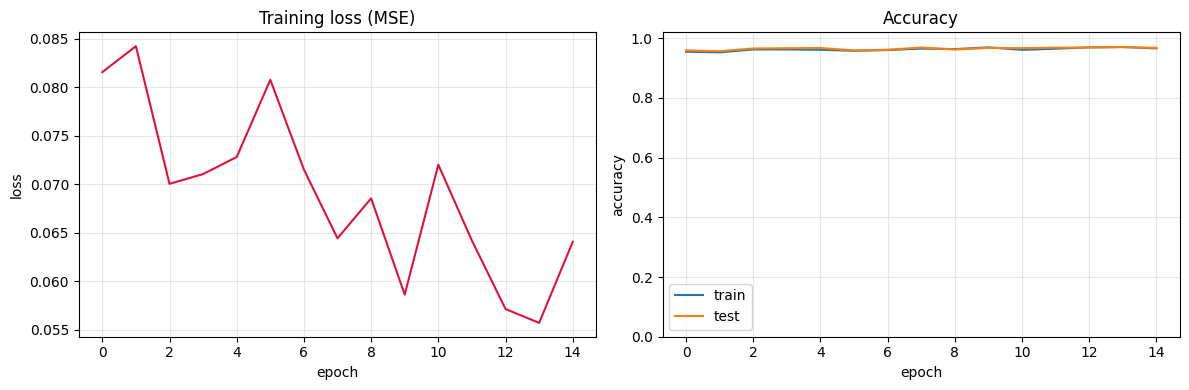

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["loss"], color="crimson")
ax1.set_title("Training loss (MSE)")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.grid(alpha=0.3)

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["test_acc"], label="test")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.set_ylim(0, 1.02); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Confusion matrix on the held-out test set

Which digits get confused with which. A strong diagonal = correct identifications.

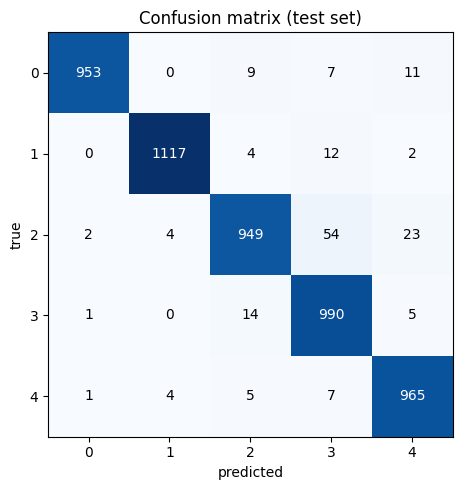

0: 0.972
1: 0.984
2: 0.920
3: 0.980
4: 0.983


In [19]:
test_probs = f_forward(X_test, w1, w2)
pred = test_probs.argmax(axis=1)

cm = np.zeros((n_classes, n_classes), dtype=int)
for true_c, pred_c in zip(y_test, pred):
    cm[true_c, pred_c] += 1

labels = [str(d) for d in DIGITS]
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes)); ax.set_xticklabels(labels)
ax.set_yticks(range(n_classes)); ax.set_yticklabels(labels)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix (test set)")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

# per-class accuracy
for c, digit in enumerate(DIGITS):
    print(f"{digit}: {cm[c, c] / cm[c].sum():.3f}")

### 4.3 Sample predictions

Predictions on random unseen test images (green = correct, red = wrong).

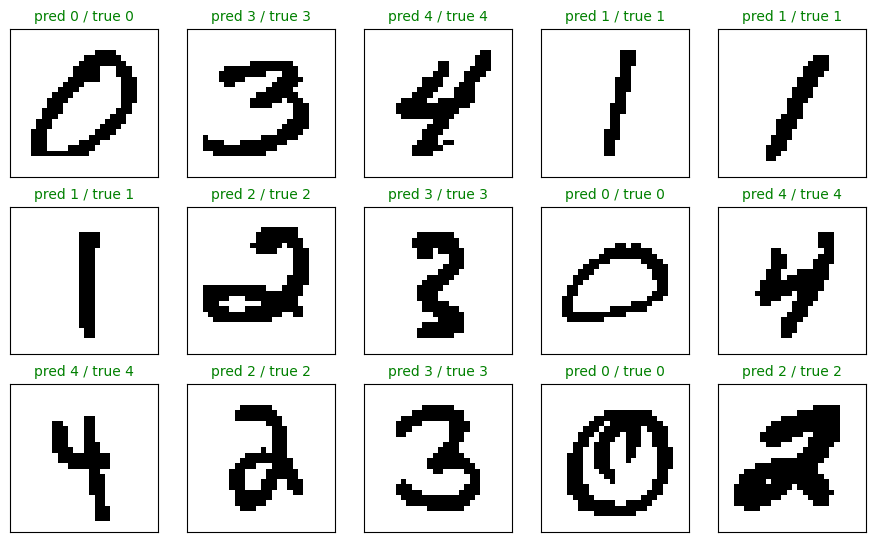

In [20]:
sample = RNG.choice(len(X_test), size=15, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(9, 5.5))
for ax, idx in zip(axes.ravel(), sample):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray_r")
    ok = pred[idx] == y_test[idx]
    ax.set_title(f"pred {DIGITS[pred[idx]]} / true {DIGITS[y_test[idx]]}",
                 color="green" if ok else "red", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### 4.4 Misclassified examples

The test images the network got **wrong** (`pred / true` in red). Inspecting these shows *how* the network fails — typically on sloppy or ambiguous handwriting that resembles another digit — rather than failing randomly.

misclassified: 165 of 5139 test images


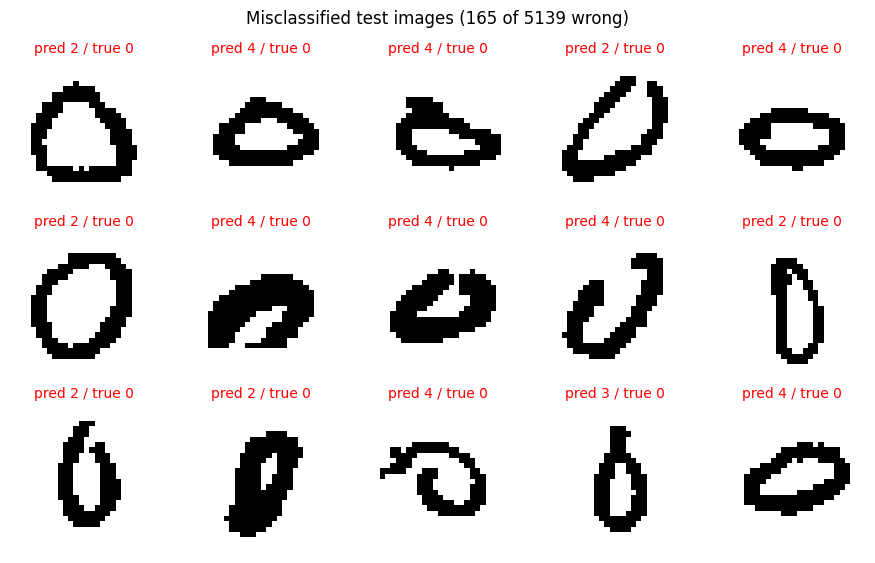

In [21]:
wrong = np.where(pred != y_test)[0]
print(f"misclassified: {len(wrong)} of {len(y_test)} test images")

if len(wrong) == 0:
    print("No misclassified test images.")
else:
    show = wrong[:15]
    cols = 5
    rows = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(9, 1.9 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, idx in zip(axes, show):
        ax.imshow(X_test[idx].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"pred {DIGITS[pred[idx]]} / true {DIGITS[y_test[idx]]}",
                     color="red", fontsize=10)
    fig.suptitle(f"Misclassified test images ({len(wrong)} of {len(y_test)} wrong)")
    plt.tight_layout()
    plt.show()

## 5. Conclusions (lecture baseline)

- This is the lecture's raw-NumPy architecture (`784 -> 5 -> 5`, sigmoid + sigmoid, MSE loss, per-sample gradient descent, no biases) applied to MNIST digits 0-4.
- Workability / efficiency are read off the cells above: the loss curve shows whether training converges, and the gap between train and test accuracy shows how well it generalizes.
- The confusion matrix and the misclassified gallery show which digits remain hard.
- This baseline is the starting point; if its accuracy is unsatisfactory we revise the architecture from here (e.g. a larger / ReLU hidden layer, softmax + cross-entropy).